<a href="https://colab.research.google.com/github/Vanitha-Jain/capstone/blob/Feature-selection/MACCS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
data=pd.read_csv('/content/MACCS.csv')
data

,Name,MACCSFP1,MACCSFP2,MACCSFP3,MACCSFP4,MACCSFP5,MACCSFP6,MACCSFP7,MACCSFP8,MACCSFP9,...,MACCSFP158,MACCSFP159,MACCSFP160,MACCSFP161,MACCSFP162,MACCSFP163,MACCSFP164,MACCSFP165,MACCSFP166,bioactivity_class
0,CHEMBL167155,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,0,inactive
1,CHEMBL166740,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,0,inactive
2,CHEMBL165038,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,0,inactive
3,CHEMBL435857,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,0,inactive
4,CHEMBL352783,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,0,inactive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,CHEMBL5429863,0,0,0,0,0,0,0,0,0,...,1,0,0,1,1,1,0,1,0,inactive
1225,CHEMBL5436920,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,0,1,0,inactive
1226,CHEMBL5405698,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,0,1,0,inactive
1227,CHEMBL5416562,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,0,1,0,inactive


In [ ]:
data.dtypes

,0
Name,object
MACCSFP1,int64
MACCSFP2,int64
MACCSFP3,int64
MACCSFP4,int64
...,...
MACCSFP163,int64
MACCSFP164,int64
MACCSFP165,int64
MACCSFP166,int64


In [ ]:
data['bioactivity_class'].replace('active', 'P', inplace=True)
data['bioactivity_class'].replace('inactive', 'N', inplace=True)
data.rename(columns = {"bioactivity_class": "class"}, inplace = True)
data

<ipython-input-3-d75cbf56e791>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['bioactivity_class'].replace('active', 'P', inplace=True)
<ipython-input-3-d75cbf56e791>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

,Name,MACCSFP1,MACCSFP2,MACCSFP3,MACCSFP4,MACCSFP5,MACCSFP6,MACCSFP7,MACCSFP8,MACCSFP9,...,MACCSFP158,MACCSFP159,MACCSFP160,MACCSFP161,MACCSFP162,MACCSFP163,MACCSFP164,MACCSFP165,MACCSFP166,class
0,CHEMBL167155,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,0,N
1,CHEMBL166740,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,0,N
2,CHEMBL165038,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,0,N
3,CHEMBL435857,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,0,N
4,CHEMBL352783,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,CHEMBL5429863,0,0,0,0,0,0,0,0,0,...,1,0,0,1,1,1,0,1,0,N
1225,CHEMBL5436920,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,0,1,0,N
1226,CHEMBL5405698,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,0,1,0,N
1227,CHEMBL5416562,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,0,1,0,N


In [ ]:
data.isnull().sum().sum()

0

In [ ]:
data.dropna(inplace =True)
data.isnull().sum().sum()

0

In [ ]:
data1 = data.iloc[:,1:167]
data1
data2 = data.iloc[:,-1]

In [ ]:
data1
data2

,class
0,N
1,N
2,N
3,N
4,N
...,...
1224,N
1225,N
1226,N
1227,N


In [ ]:
from sklearn.feature_selection import VarianceThreshold
threshold = VarianceThreshold(threshold=.1)
def variance_threshold_selector(data1, threshold=0.10):
    selector = VarianceThreshold(threshold)
    selector.fit(data1)
    return data[data1.columns[selector.get_support(indices=True)]]
data1_HV = variance_threshold_selector(data1)

In [ ]:
data1_HV = variance_threshold_selector(data1)
data1_HV

,MACCSFP16,MACCSFP32,MACCSFP33,MACCSFP37,MACCSFP38,MACCSFP42,MACCSFP50,MACCSFP51,MACCSFP52,MACCSFP53,...,MACCSFP152,MACCSFP153,MACCSFP154,MACCSFP155,MACCSFP156,MACCSFP157,MACCSFP158,MACCSFP159,MACCSFP160,MACCSFP161
0,1,1,1,0,0,0,0,1,0,1,...,1,0,1,0,1,1,1,1,1,1
1,1,1,1,0,0,0,0,1,0,1,...,0,0,1,0,1,1,1,1,1,1
2,1,1,1,0,0,0,0,1,0,1,...,0,0,1,0,1,1,1,1,1,1
3,1,1,1,0,0,0,0,1,0,1,...,0,0,1,0,1,1,1,1,1,1
4,1,1,1,0,0,0,0,1,0,1,...,0,0,1,0,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,1
1225,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
1226,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
1227,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [ ]:
data2_HV = pd.merge(data1_HV,data2,left_index=True,right_index=True)
data2_HV

,MACCSFP16,MACCSFP32,MACCSFP33,MACCSFP37,MACCSFP38,MACCSFP42,MACCSFP50,MACCSFP51,MACCSFP52,MACCSFP53,...,MACCSFP153,MACCSFP154,MACCSFP155,MACCSFP156,MACCSFP157,MACCSFP158,MACCSFP159,MACCSFP160,MACCSFP161,class
0,1,1,1,0,0,0,0,1,0,1,...,0,1,0,1,1,1,1,1,1,N
1,1,1,1,0,0,0,0,1,0,1,...,0,1,0,1,1,1,1,1,1,N
2,1,1,1,0,0,0,0,1,0,1,...,0,1,0,1,1,1,1,1,1,N
3,1,1,1,0,0,0,0,1,0,1,...,0,1,0,1,1,1,1,1,1,N
4,1,1,1,0,0,0,0,1,0,1,...,0,1,0,1,1,1,1,1,1,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,1,N
1225,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,N
1226,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,N
1227,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,N


In [ ]:
## remove features that display high correlation with many other features
correlated_features_1 = set()
corr_matrix_class = data2_HV.corr(numeric_only=True)


for i in range(len(corr_matrix_class.columns)):
    for j in range(i):
        if abs(corr_matrix_class.iloc[i, j]) > 0.9:
            colname = corr_matrix_class.columns[i]
            correlated_features_1.add(colname)
correlated_features_1

{'MACCSFP110',
 'MACCSFP119',
 'MACCSFP124',
 'MACCSFP134',
 'MACCSFP143',
 'MACCSFP147',
 'MACCSFP148',
 'MACCSFP161',
 'MACCSFP33',
 'MACCSFP55',
 'MACCSFP58',
 'MACCSFP60',
 'MACCSFP61',
 'MACCSFP64',
 'MACCSFP67',
 'MACCSFP73',
 'MACCSFP76',
 'MACCSFP88'}

In [ ]:
def remove_correlated_features(features, data):
    for x in features:
        data.drop(x, axis=1, inplace=True)
    return data

In [ ]:
data3= remove_correlated_features(correlated_features_1, data2_HV)
data3

,MACCSFP16,MACCSFP32,MACCSFP37,MACCSFP38,MACCSFP42,MACCSFP50,MACCSFP51,MACCSFP52,MACCSFP53,MACCSFP54,...,MACCSFP152,MACCSFP153,MACCSFP154,MACCSFP155,MACCSFP156,MACCSFP157,MACCSFP158,MACCSFP159,MACCSFP160,class
0,1,1,0,0,0,0,1,0,1,0,...,1,0,1,0,1,1,1,1,1,N
1,1,1,0,0,0,0,1,0,1,0,...,0,0,1,0,1,1,1,1,1,N
2,1,1,0,0,0,0,1,0,1,0,...,0,0,1,0,1,1,1,1,1,N
3,1,1,0,0,0,0,1,0,1,0,...,0,0,1,0,1,1,1,1,1,N
4,1,1,0,0,0,0,1,0,1,0,...,0,0,1,0,1,1,1,1,1,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,N
1225,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,N
1226,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,N
1227,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,N


In [ ]:
data3.to_csv('MACCS2.csv')

In [ ]:
X = data3.iloc[:,1:93]  #independent columns
X
y = data3.iloc[:,-1]
y   #target column i.e price range

,class
0,N
1,N
2,N
3,N
4,N
...,...
1224,N
1225,N
1226,N
1227,N


In [ ]:
X

,MACCSFP32,MACCSFP37,MACCSFP38,MACCSFP42,MACCSFP50,MACCSFP51,MACCSFP52,MACCSFP53,MACCSFP54,MACCSFP57,...,MACCSFP151,MACCSFP152,MACCSFP153,MACCSFP154,MACCSFP155,MACCSFP156,MACCSFP157,MACCSFP158,MACCSFP159,MACCSFP160
0,1,0,0,0,0,1,0,1,0,0,...,1,1,0,1,0,1,1,1,1,1
1,1,0,0,0,0,1,0,1,0,0,...,1,0,0,1,0,1,1,1,1,1
2,1,0,0,0,0,1,0,1,0,0,...,1,0,0,1,0,1,1,1,1,1
3,1,0,0,0,0,1,0,1,0,0,...,1,0,0,1,0,1,1,1,1,1
4,1,0,0,0,0,1,0,1,0,0,...,1,0,0,1,0,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,1,0,0
1225,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1226,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1227,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
from sklearn.preprocessing import StandardScaler
# y = data['class']
# X_features =data.drop(columns='class')
scaler = StandardScaler()
X_transform = scaler.fit_transform(X)
X_transform_pd = pd.DataFrame(X_transform, columns = X.columns)
X_transform_pd

# #Standardize/normalize the data
# from sklearn.preprocessing import MinMaxScaler
# sc = MinMaxScaler()
# X_transform = sc.fit_transform(X)
# X_transform

,MACCSFP32,MACCSFP37,MACCSFP38,MACCSFP42,MACCSFP50,MACCSFP51,MACCSFP52,MACCSFP53,MACCSFP54,MACCSFP57,...,MACCSFP151,MACCSFP152,MACCSFP153,MACCSFP154,MACCSFP155,MACCSFP156,MACCSFP157,MACCSFP158,MACCSFP159,MACCSFP160
0,2.594140,-0.385484,-0.706244,-0.484949,-0.411537,2.692271,-0.500254,2.302730,-0.392416,-0.672844,...,0.891157,0.672844,-1.447659,0.646167,-1.313414,0.418273,0.562002,0.488786,0.427631,0.539413
1,2.594140,-0.385484,-0.706244,-0.484949,-0.411537,2.692271,-0.500254,2.302730,-0.392416,-0.672844,...,0.891157,-1.486229,-1.447659,0.646167,-1.313414,0.418273,0.562002,0.488786,0.427631,0.539413
2,2.594140,-0.385484,-0.706244,-0.484949,-0.411537,2.692271,-0.500254,2.302730,-0.392416,-0.672844,...,0.891157,-1.486229,-1.447659,0.646167,-1.313414,0.418273,0.562002,0.488786,0.427631,0.539413
3,2.594140,-0.385484,-0.706244,-0.484949,-0.411537,2.692271,-0.500254,2.302730,-0.392416,-0.672844,...,0.891157,-1.486229,-1.447659,0.646167,-1.313414,0.418273,0.562002,0.488786,0.427631,0.539413
4,2.594140,-0.385484,-0.706244,-0.484949,-0.411537,2.692271,-0.500254,2.302730,-0.392416,-0.672844,...,0.891157,-1.486229,-1.447659,0.646167,-1.313414,0.418273,0.562002,0.488786,0.427631,0.539413
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,-0.385484,-0.385484,-0.706244,-0.484949,-0.411537,-0.371434,-0.500254,-0.434267,-0.392416,-0.672844,...,0.891157,-1.486229,-1.447659,-1.547588,-1.313414,0.418273,-1.779354,0.488786,-2.338466,-1.853867
1225,-0.385484,-0.385484,-0.706244,-0.484949,-0.411537,-0.371434,-0.500254,-0.434267,-0.392416,-0.672844,...,-1.122137,-1.486229,-1.447659,-1.547588,-1.313414,0.418273,-1.779354,-2.045887,-2.338466,-1.853867
1226,-0.385484,-0.385484,-0.706244,-0.484949,-0.411537,-0.371434,-0.500254,-0.434267,-0.392416,-0.672844,...,-1.122137,-1.486229,-1.447659,-1.547588,-1.313414,0.418273,-1.779354,-2.045887,-2.338466,-1.853867
1227,-0.385484,-0.385484,-0.706244,-0.484949,-0.411537,-0.371434,-0.500254,-0.434267,-0.392416,-0.672844,...,-1.122137,-1.486229,-1.447659,-1.547588,-1.313414,0.418273,-1.779354,-2.045887,-2.338466,-1.853867


In [ ]:
## Split data into train and test sets.
from sklearn.model_selection import train_test_split
seed_num = 10
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3, random_state=seed_num)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(860, 92)
(860,)
(369, 92)
(369,)


In [ ]:
X_train

,MACCSFP32,MACCSFP37,MACCSFP38,MACCSFP42,MACCSFP50,MACCSFP51,MACCSFP52,MACCSFP53,MACCSFP54,MACCSFP57,...,MACCSFP151,MACCSFP152,MACCSFP153,MACCSFP154,MACCSFP155,MACCSFP156,MACCSFP157,MACCSFP158,MACCSFP159,MACCSFP160
387,0,0,0,0,0,0,0,0,0,1,...,1,1,1,0,1,1,0,1,0,1
250,1,0,0,1,0,1,0,0,0,0,...,1,0,0,0,0,1,0,1,1,1
378,0,0,1,0,1,0,0,1,1,1,...,1,1,1,0,1,1,1,1,1,0
73,0,0,0,0,0,0,0,0,0,0,...,1,1,0,1,0,1,1,1,1,0
1185,0,1,0,0,0,0,0,0,0,0,...,1,1,0,1,0,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0,0,0,0,0,0,0,0,0,0,...,0,1,1,1,1,1,1,1,1,1
1180,0,1,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
1147,0,0,0,1,0,0,0,0,0,0,...,0,1,1,1,1,1,1,1,1,1
527,1,0,0,0,0,1,1,0,0,1,...,0,1,1,1,1,1,1,1,1,1


In [ ]:
y_train

,class
387,N
250,N
378,N
73,N
1185,P
...,...
733,N
1180,P
1147,N
527,P


In [ ]:
Training_set  = pd.concat([X_train,y_train],axis=1)
Training_set

,MACCSFP32,MACCSFP37,MACCSFP38,MACCSFP42,MACCSFP50,MACCSFP51,MACCSFP52,MACCSFP53,MACCSFP54,MACCSFP57,...,MACCSFP152,MACCSFP153,MACCSFP154,MACCSFP155,MACCSFP156,MACCSFP157,MACCSFP158,MACCSFP159,MACCSFP160,class
387,0,0,0,0,0,0,0,0,0,1,...,1,1,0,1,1,0,1,0,1,N
250,1,0,0,1,0,1,0,0,0,0,...,0,0,0,0,1,0,1,1,1,N
378,0,0,1,0,1,0,0,1,1,1,...,1,1,0,1,1,1,1,1,0,N
73,0,0,0,0,0,0,0,0,0,0,...,1,0,1,0,1,1,1,1,0,N
1185,0,1,0,0,0,0,0,0,0,0,...,1,0,1,0,1,1,1,1,1,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,N
1180,0,1,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,P
1147,0,0,0,1,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,N
527,1,0,0,0,0,1,1,0,0,1,...,1,1,1,1,1,1,1,1,1,P


In [ ]:
Training_set.to_csv('MACCS_Training_set.csv')

In [ ]:
Testing_set  = pd.concat([X_test,y_test],axis=1)
Testing_set

,MACCSFP32,MACCSFP37,MACCSFP38,MACCSFP42,MACCSFP50,MACCSFP51,MACCSFP52,MACCSFP53,MACCSFP54,MACCSFP57,...,MACCSFP152,MACCSFP153,MACCSFP154,MACCSFP155,MACCSFP156,MACCSFP157,MACCSFP158,MACCSFP159,MACCSFP160,class
693,0,0,0,0,0,0,1,1,1,1,...,1,1,1,1,1,1,1,1,0,N
834,0,0,1,0,0,0,1,0,0,0,...,1,1,0,1,1,1,1,0,1,N
1016,0,0,1,0,0,0,0,1,1,0,...,1,0,1,0,1,1,1,1,1,P
1113,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,0,1,0,1,1,P
31,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,1,1,0,1,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,1,0,1,1,0,1,0,0,0,0,...,0,1,0,0,1,0,1,1,1,P
909,0,1,1,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,P
270,1,0,0,1,0,1,0,0,0,0,...,0,0,0,0,1,0,1,1,1,N
349,0,0,0,0,0,0,0,0,0,1,...,1,1,1,1,1,1,1,1,1,P


In [ ]:
Testing_set.to_csv('MACCS_Testing_set.csv')

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
kBest = SelectKBest(mutual_info_classif, k = 15)
X_kBestFeatures = kBest.fit_transform(X_train, y_train)
X_kBestFeatures.shape

(860, 15)

In [ ]:
kBest.get_support(True)

array([ 1, 12, 24, 30, 37, 44, 46, 48, 61, 63, 71, 74, 79, 85, 89])

In [ ]:
X_kBestFeatures = Training_set.iloc[:, kBest.get_support(True)]
X_kBestFeatures.columns

Index(['MACCSFP37', 'MACCSFP65', 'MACCSFP83', 'MACCSFP91', 'MACCSFP98',
       'MACCSFP106', 'MACCSFP108', 'MACCSFP111', 'MACCSFP126', 'MACCSFP128',
       'MACCSFP137', 'MACCSFP140', 'MACCSFP146', 'MACCSFP154', 'MACCSFP158'],
      dtype='object')

In [ ]:
f = kBest.get_support(1)
X_new = X_train[X_train.columns[f]]
X_new
data_scores = pd.DataFrame(kBest.scores_)
data_columns = pd.DataFrame(X.columns)

In [ ]:
#Concat two dataframes for better visualization
featureScores = pd.concat([data_columns, data_scores], axis = 1)

#naming the dataframe columns
featureScores.columns = ['Features', 'Scores']
featureScores

,Features,Scores
0,MACCSFP32,0.018625
1,MACCSFP37,0.033690
2,MACCSFP38,0.011329
3,MACCSFP42,0.028935
4,MACCSFP50,0.013418
...,...,...
87,MACCSFP156,0.006536
88,MACCSFP157,0.000000
89,MACCSFP158,0.029507
90,MACCSFP159,0.008735


In [ ]:
#Print top 25 best features
print(featureScores.nlargest(15, 'Scores'))

      Features    Scores
61  MACCSFP126  0.065648
74  MACCSFP140  0.046300
85  MACCSFP154  0.043902
63  MACCSFP128  0.042693
12   MACCSFP65  0.040599
46  MACCSFP108  0.036647
1    MACCSFP37  0.033690
79  MACCSFP146  0.032564
44  MACCSFP106  0.032003
30   MACCSFP91  0.031820
71  MACCSFP137  0.031600
37   MACCSFP98  0.031502
24   MACCSFP83  0.031330
48  MACCSFP111  0.029792
89  MACCSFP158  0.029507


In [ ]:
Graph = (featureScores.nlargest(15, 'Scores'))
Graph

,Features,Scores
61,MACCSFP126,0.065648
74,MACCSFP140,0.046300
85,MACCSFP154,0.043902
63,MACCSFP128,0.042693
12,MACCSFP65,0.040599
46,MACCSFP108,0.036647
1,MACCSFP37,0.033690
79,MACCSFP146,0.032564
44,MACCSFP106,0.032003
30,MACCSFP91,0.031820


In [ ]:
Graph.to_csv('MACCS_Features.csv')

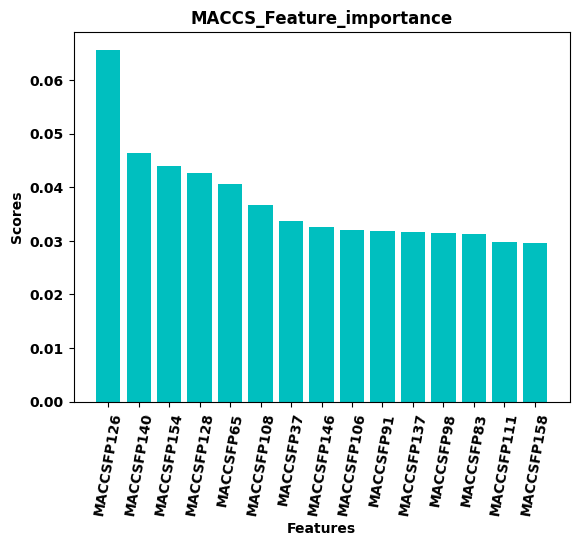

<Figure size 1000x1000 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
data = pd.read_csv('MACCS_Features.csv')
df = pd.DataFrame(data)
X = list(df.iloc[:, 1])
Y = list(df.iloc[:, 2])
plt.bar(X, Y, color='c')
plt.title("MACCS_Feature_importance", fontweight="bold")
plt.xlabel("Features", fontweight = 'bold')
plt.ylabel("Scores", fontweight = 'bold')
plt.xticks(rotation = 80, fontweight="bold")
plt.yticks(fontweight="bold")
fig = plt.figure(figsize=(10, 10))
plt.savefig("Features.jpg", bbox_inches = 'tight')

In [ ]:
Trainset = pd.concat([X_new,y_train],axis=1)
Trainset

,MACCSFP37,MACCSFP65,MACCSFP83,MACCSFP91,MACCSFP98,MACCSFP106,MACCSFP108,MACCSFP111,MACCSFP126,MACCSFP128,MACCSFP137,MACCSFP140,MACCSFP146,MACCSFP154,MACCSFP158,class
387,0,1,1,0,1,0,0,1,0,0,1,0,0,0,1,N
250,0,1,1,0,1,1,0,0,0,0,1,0,0,0,1,N
378,0,1,1,1,1,1,0,1,0,1,1,1,1,0,1,N
73,0,1,1,0,0,0,0,0,0,0,1,1,1,1,1,N
1185,1,1,0,1,1,1,0,1,1,0,1,1,1,1,1,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0,0,0,0,1,0,1,1,1,1,1,0,0,1,1,N
1180,1,1,0,1,1,1,0,1,1,1,1,1,1,1,1,P
1147,0,0,0,0,1,1,1,1,1,1,1,0,0,1,1,N
527,0,1,1,0,1,1,0,1,0,1,1,1,1,1,1,P


In [ ]:
f = kBest.get_support(1)
Test_new = X_test[X_test.columns[f]]
Test_new

,MACCSFP37,MACCSFP65,MACCSFP83,MACCSFP91,MACCSFP98,MACCSFP106,MACCSFP108,MACCSFP111,MACCSFP126,MACCSFP128,MACCSFP137,MACCSFP140,MACCSFP146,MACCSFP154,MACCSFP158
693,0,1,1,1,0,0,0,0,0,0,1,1,1,1,1
834,0,1,1,0,0,0,0,0,1,0,1,0,0,0,1
1016,0,1,1,0,1,0,0,0,1,0,1,1,1,1,1
1113,0,0,0,0,0,0,0,0,1,0,0,1,1,1,0
31,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,0,1,1,0,1,1,0,1,0,1,1,0,0,0,1
909,1,1,0,1,1,1,0,1,1,1,1,1,1,1,1
270,0,1,1,0,1,1,0,1,0,0,1,0,0,0,1
349,0,0,1,1,0,0,1,1,1,1,1,1,1,1,1


In [ ]:
Testset = pd.concat([Test_new,y_test],axis=1)
Testset

,MACCSFP37,MACCSFP65,MACCSFP83,MACCSFP91,MACCSFP98,MACCSFP106,MACCSFP108,MACCSFP111,MACCSFP126,MACCSFP128,MACCSFP137,MACCSFP140,MACCSFP146,MACCSFP154,MACCSFP158,class
693,0,1,1,1,0,0,0,0,0,0,1,1,1,1,1,N
834,0,1,1,0,0,0,0,0,1,0,1,0,0,0,1,N
1016,0,1,1,0,1,0,0,0,1,0,1,1,1,1,1,P
1113,0,0,0,0,0,0,0,0,1,0,0,1,1,1,0,P
31,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,0,1,1,0,1,1,0,1,0,1,1,0,0,0,1,P
909,1,1,0,1,1,1,0,1,1,1,1,1,1,1,1,P
270,0,1,1,0,1,1,0,1,0,0,1,0,0,0,1,N
349,0,0,1,1,0,0,1,1,1,1,1,1,1,1,1,P


In [ ]:
Trainset.to_csv('Trainset_MACCS_after_feature.csv')
Testset.to_csv('Testset_MACCS_after_feature.csv')

In [ ]:
Trainset['class'].replace('N', 0, inplace=True)
Trainset['class'].replace('P', 1, inplace=True)
Trainset.rename(columns = {"class": "class"}, inplace = True)
Trainset

<ipython-input-38-e976ed617192>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Trainset['class'].replace('N', 0, inplace=True)
<ipython-input-38-e976ed617192>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

,MACCSFP37,MACCSFP65,MACCSFP83,MACCSFP91,MACCSFP98,MACCSFP106,MACCSFP108,MACCSFP111,MACCSFP126,MACCSFP128,MACCSFP137,MACCSFP140,MACCSFP146,MACCSFP154,MACCSFP158,class
387,0,1,1,0,1,0,0,1,0,0,1,0,0,0,1,0
250,0,1,1,0,1,1,0,0,0,0,1,0,0,0,1,0
378,0,1,1,1,1,1,0,1,0,1,1,1,1,0,1,0
73,0,1,1,0,0,0,0,0,0,0,1,1,1,1,1,0
1185,1,1,0,1,1,1,0,1,1,0,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0,0,0,0,1,0,1,1,1,1,1,0,0,1,1,0
1180,1,1,0,1,1,1,0,1,1,1,1,1,1,1,1,1
1147,0,0,0,0,1,1,1,1,1,1,1,0,0,1,1,0
527,0,1,1,0,1,1,0,1,0,1,1,1,1,1,1,1


In [ ]:
Testset['class'].replace('N', 0, inplace=True)
Testset['class'].replace('P', 1, inplace=True)
Testset.rename(columns = {"class": "class"}, inplace = True)
Testset.head()

<ipython-input-39-c538cf0d9b31>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Testset['class'].replace('N', 0, inplace=True)
<ipython-input-39-c538cf0d9b31>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

,MACCSFP37,MACCSFP65,MACCSFP83,MACCSFP91,MACCSFP98,MACCSFP106,MACCSFP108,MACCSFP111,MACCSFP126,MACCSFP128,MACCSFP137,MACCSFP140,MACCSFP146,MACCSFP154,MACCSFP158,class
693,0,1,1,1,0,0,0,0,0,0,1,1,1,1,1,0
834,0,1,1,0,0,0,0,0,1,0,1,0,0,0,1,0
1016,0,1,1,0,1,0,0,0,1,0,1,1,1,1,1,1
1113,0,0,0,0,0,0,0,0,1,0,0,1,1,1,0,1
31,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,1


In [ ]:
Trainset.to_csv('Trainset1_MACCS_after_feature.csv')
Testset.to_csv('Testset1_MACCS_after_feature.csv')